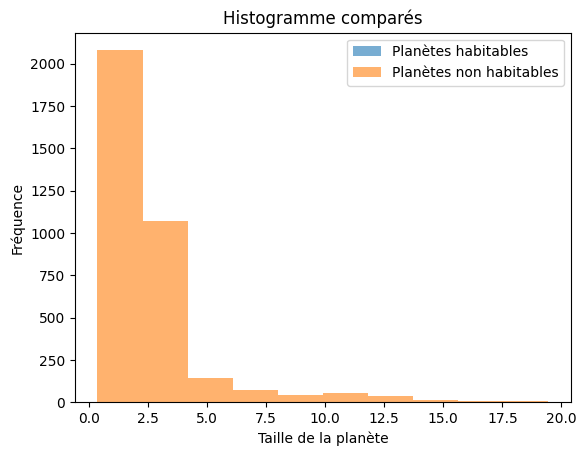

Diff obs : -1.461067975995636
p-value :  0.0286


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

#Please move to /reports/claim-2.md to read to final claim of this project

df = pd.read_csv('../data/raw/kepler.csv')
#our claim is that all habitable planets are small 
habitable_planets = df[df['is_habitable'] == True]
non_habitable_planets = df[df['is_habitable']==False]

plt.hist(habitable_planets['koi_prad'],alpha=0.6,label="Planètes habitables")
plt.hist(non_habitable_planets['koi_prad'],alpha=0.6,label="Planètes non habitables")
plt.xlabel('Taille de la planète')
plt.ylabel('Fréquence')

plt.legend()
plt.title("Histogramme comparés")
plt.show()

#comparison 
group_a = habitable_planets['koi_prad'].dropna().values
group_b =non_habitable_planets['koi_prad'].dropna().values
mean_a = np.mean(group_a)
mean_b = np.mean(group_b)
diff_obs = mean_a-mean_b

print("Diff obs :",diff_obs)

all_data = np.concatenate([group_a,group_b])
n_a = len(group_a)

n_perm =5000
perm_diffs=[]

for _ in range(n_perm):
    shuffled_data = np.random.permutation(all_data)
    perm_a = shuffled_data[:n_a]
    perm_b= shuffled_data[n_a:]
    diff = np.mean(perm_a)-np.mean(perm_b)
    perm_diffs.append(diff)

    
perm_diffs = np.array(perm_diffs)

p_value = np.mean(np.abs(perm_diffs)>= abs(diff_obs))

print("p-value : ",p_value)


